[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_4/04B-RandomForests.ipynb)

# 04B — Random Forests

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 4, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`04A` ended on a problem rather than a result. Three bootstrap resamples of the same 150 flowers
gave three different trees — different questions, different thresholds, different partitions of the
plane. A single tree is a **low-bias, high-variance** model in exactly `03B`'s sense: it can
represent almost anything, and it changes a great deal when the data change a little.

`03B` also gave the standard cure for variance, and its third exercise had you build it by hand:
**average many independent estimates**. This notebook applies that to trees, finds that the obvious
version is not quite enough, and fixes it with one further idea. The result is the model that wins
most competitions on tabular scientific data that a neural network does not.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain **bagging** — bootstrap the data, fit a model to each resample, aggregate the answers —
  and why it reduces variance without increasing bias;
- say why bagged trees are still too similar to each other, and measure how similar;
- explain the **random subspace** trick that makes a bagging ensemble a **random forest**, and what
  `max_features` controls;
- choose `n_estimators`, and explain why more trees never overfits while more depth does;
- use the **out-of-bag** score as validation that costs nothing;
- read a **feature importance** and name the three ways it misleads.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import (cross_val_score, train_test_split,
                                     RepeatedStratifiedKFold)
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)

# 1. One tree is a noisy estimate

The iris flowers of `04A` were convenient for drawing but too easy to argue with. This notebook uses
a harder and more typical dataset: **569 breast tumour samples**, each described by thirty
measurements taken from a digitised image of a fine-needle aspirate — radius, texture, perimeter,
area, concavity and so on, each reported as a mean, a standard error and a "worst" value. The task
is to classify the sample as malignant or benign.

Thirty features and a few hundred samples is the shape of an enormous amount of scientific data,
and it is the shape trees are good at.

The first cell fits fifty trees, each to a different **bootstrap resample** of the same training
set — 398 patients drawn from those same 398 with replacement, as in `04A` §11.3. Section 2 says
what the bootstrap is and why it is the right tool here; for the moment it is only a way of
producing fifty slightly different training sets out of one. The question the cell asks is how much
the fifty trees disagree.

In [2]:
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

resample = np.random.default_rng(0)
predictions = []
for _ in range(50):
    rows = resample.integers(0, len(y_train), len(y_train))
    tree = DecisionTreeClassifier(random_state=0).fit(X_train.iloc[rows], y_train.iloc[rows])
    predictions.append(tree.predict(X_test))
predictions = np.array(predictions)

accuracies = (predictions == y_test.to_numpy()).mean(axis=1)
share_benign = predictions.mean(axis=0)
contested = (share_benign > 0) & (share_benign < 1)

print(f"{len(y)} samples, {X.shape[1]} measurements each")
print(f"\nfifty trees, each on its own resample of the same training data:")
print(f"   accuracy on the test set:  worst {accuracies.min():.3f}"
      f"   best {accuracies.max():.3f}   spread {accuracies.max() - accuracies.min():.3f}")
print(f"   test samples the fifty trees do not all agree about: "
      f"{contested.sum()} of {len(y_test)}")

569 samples, 30 measurements each

fifty trees, each on its own resample of the same training data:
   accuracy on the test set:  worst 0.883   best 0.947   spread 0.064
   test samples the fifty trees do not all agree about: 51 of 171


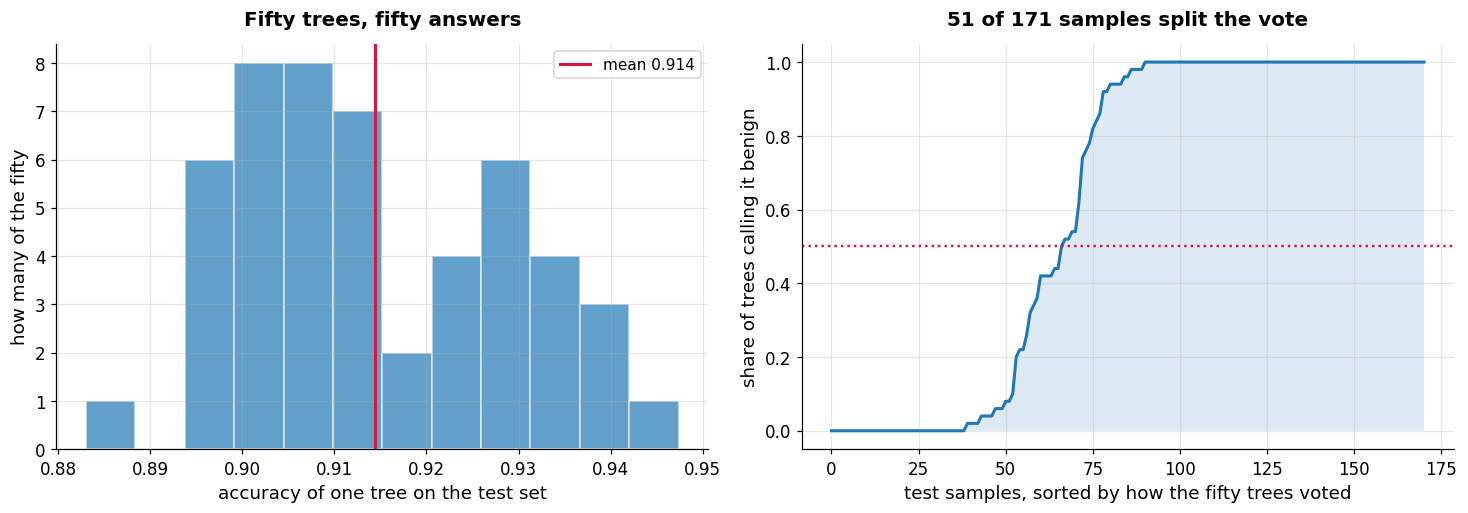

In [3]:
fig, (spread, votes) = plt.subplots(1, 2, figsize=(13.5, 4.8))

spread.hist(accuracies, bins=12, color="tab:blue", alpha=0.7, edgecolor="white")
spread.axvline(accuracies.mean(), color="crimson", linewidth=2,
               label=f"mean {accuracies.mean():.3f}")
spread.set_xlabel("accuracy of one tree on the test set")
spread.set_ylabel("how many of the fifty")
spread.set_title("Fifty trees, fifty answers")
spread.legend()

order = np.argsort(share_benign)
votes.plot(np.arange(len(y_test)), share_benign[order], linewidth=2)
votes.fill_between(np.arange(len(y_test)), 0, share_benign[order], alpha=0.15)
votes.axhline(0.5, color="crimson", linestyle=":", linewidth=1.6)
votes.set_xlabel("test samples, sorted by how the fifty trees voted")
votes.set_ylabel("share of trees calling it benign")
votes.set_title(f"{contested.sum()} of {len(y_test)} samples split the vote")
plt.show()

Two readings, one per panel.

**No tree is the tree.** The fifty differ by several points of accuracy, and nothing distinguishes
the best from the worst except which bootstrap sample it happened to see. Reporting any one of them
as *the* result would be reporting an accident.

**But they do not disagree everywhere.** The right-hand panel sorts the test samples by how the vote
went. At both ends the curve is flat: for most samples all fifty trees say the same thing, and those
are the easy ones. The disagreement is concentrated in the middle — the samples near the boundary,
where a slightly different tree draws the line on the other side.

That shape is the opportunity. If the trees were wrong in the *same* way there would be nothing to
gain by combining them. They are wrong in *different* ways, and different errors can cancel.

# 2. Bagging: bootstrap, then aggregate

`03B` §7 established the rule this rests on. Averaging $B$ independent estimates leaves the bias
where it was and divides the variance by $B$:

$$
\operatorname{Var}\Bigl[\tfrac{1}{B}\textstyle\sum_b \hat{f}_b\Bigr]
\;=\; \frac{\sigma^2}{B}
\qquad\text{when the } \hat{f}_b \text{ are independent.}
$$

A tree is a low-bias, high-variance estimator, so it is exactly the thing this helps most: there is
little bias to be stuck with, and a great deal of variance to divide.

The obstacle is that we have one dataset, not $B$ of them. Manufacturing the missing ones is what
the **bootstrap** does, and `03C` §4 and `04A` §11.3 have both already borrowed it. Here it stops
being a convenience and becomes the method, so it is worth stating properly.

### The bootstrap

We want to know what a quantity would do if the experiment were repeated. The honest way is to
repeat it, and we cannot: the 398 patients are all there are.

The bootstrap's answer is to treat the sample we hold as a stand-in for the population it came from,
and to draw fresh samples *from it*. To build one **bootstrap resample** of $n$ observations, draw
$n$ times from the training set **with replacement** — each draw is made from the whole set, so an
observation already taken can be taken again.

That last phrase does all the work. Drawing $n$ observations *without* replacement would return the
same $n$ observations in a different order, which is no new dataset at all. Drawing with replacement
returns a set of the same size in which some observations appear twice or three times, some appear
once, and some do not appear at all.

Two consequences matter later. A resample is the same size as the original, so nothing has to be set
aside to make one. And a substantial share of the original observations is missing from any given
resample — section 6 measures that share and finds a use for it.

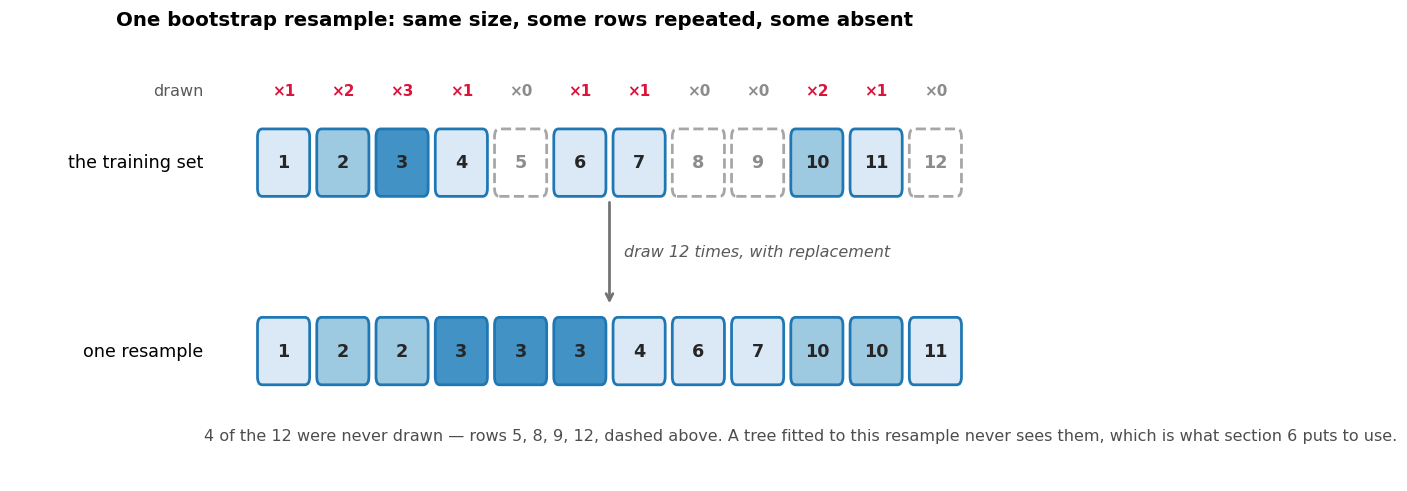

In [ ]:
# One bootstrap resample of a small training set, drawn so the mechanics are visible.
# Twelve rows rather than 398, for the same reason every diagram in this course uses few points.

show = np.random.default_rng(3)
n_show = 12
drawn = np.sort(show.integers(0, n_show, n_show))       # 12 draws, with replacement
times_drawn = np.bincount(drawn, minlength=n_show)

fig, axis = plt.subplots(figsize=(12.5, 4.6))
box_w, box_h = 0.82, 0.62
shades = {0: "white", 1: "#dbe9f6", 2: "#9ecae1", 3: "#4292c6"}

def box(x, y, label, face, edge, text_colour="0.15", dashed=False):
    axis.add_patch(FancyBboxPatch((x - box_w / 2, y - box_h / 2), box_w, box_h,
                                  boxstyle="round,pad=0.03,rounding_size=0.08",
                                  facecolor=face, edgecolor=edge, linewidth=1.8,
                                  linestyle="--" if dashed else "-", zorder=2))
    axis.text(x, y, label, ha="center", va="center", fontsize=11.5, zorder=4,
              fontweight="bold", color=text_colour)

for i in range(n_show):                                  # the training set, shaded by draw count
    out = times_drawn[i] == 0
    box(i, 1.5, str(i + 1), shades[times_drawn[i]],
        "0.65" if out else "tab:blue", "0.55" if out else "0.15", dashed=out)
    axis.text(i, 2.22, f"×{times_drawn[i]}", ha="center", va="center", fontsize=10,
              color="0.55" if out else "crimson", fontweight="bold")

for slot, source in enumerate(drawn):                    # the resample itself
    box(slot, -0.4, str(source + 1), shades[min(times_drawn[source], 3)], "tab:blue")

axis.text(-1.35, 2.22, "drawn", ha="right", va="center", fontsize=10.5, color="0.35")
axis.text(-1.35, 1.5, "the training set", ha="right", va="center", fontsize=11.5)
axis.text(-1.35, -0.4, "one resample", ha="right", va="center", fontsize=11.5)

axis.annotate("", xy=(5.5, 0.05), xytext=(5.5, 1.13),
              arrowprops={"arrowstyle": "->", "linewidth": 1.8, "color": "0.45"})
axis.text(5.75, 0.6, "draw 12 times, with replacement", fontsize=10.5,
          style="italic", color="0.35", va="center")

never = np.flatnonzero(times_drawn == 0)
axis.text(-1.35, -1.25,
          f"{len(never)} of the {n_show} were never drawn — rows "
          f"{', '.join(str(i + 1) for i in never)}, dashed above. A tree fitted to this resample "
          f"never sees them, which is what section 6 puts to use.",
          ha="left", va="center", fontsize=10.5, color="0.3")

axis.set_xlim(-4.6, n_show + 0.4)
axis.set_ylim(-1.7, 2.7)
axis.axis("off")
axis.set_title("One bootstrap resample: same size, some rows repeated, some absent")
plt.show()

Read the figure as one draw. Row 3 was picked three times and appears three times in the resample;
rows 5, 8, 9 and 12 were picked not at all and are absent from it. The resample still has twelve
rows, and it is not the training set.

Do that $B$ times, fit a tree to each, and aggregate the answers — bootstrap, then aggregate, which
is **bagging**. `BaggingClassifier` does both.

         a single tree: 0.9274   (standard error 0.0035)


    bagging, 200 trees: 0.9561   (standard error 0.0039)

errors removed by averaging: 2.9 percentage points


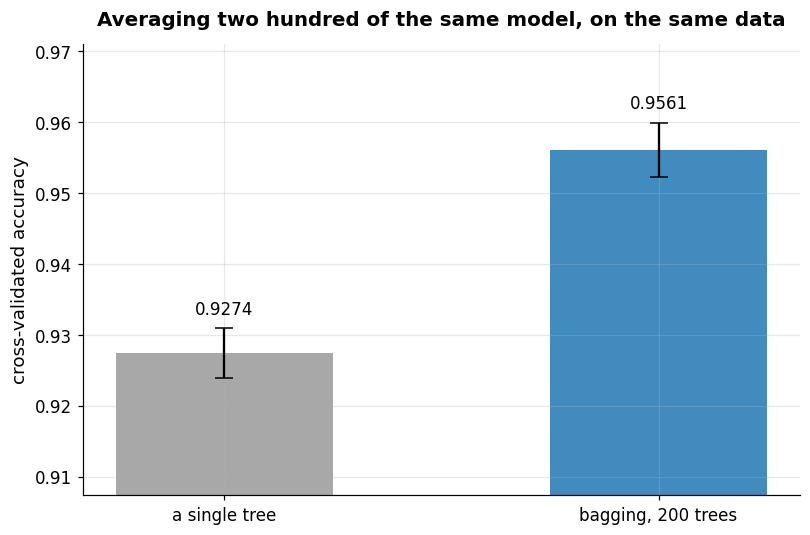

In [4]:
subsets = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=0)

compared = {}
for name, model in [
        ("a single tree", DecisionTreeClassifier(random_state=0)),
        ("bagging, 200 trees", BaggingClassifier(DecisionTreeClassifier(random_state=0),
                                                 n_estimators=200, random_state=0))]:
    scored = cross_val_score(model, X, y, cv=subsets, n_jobs=-1)
    compared[name] = scored
    print(f"{name:>22}: {scored.mean():.4f}   (standard error {scored.std() / np.sqrt(len(scored)):.4f})")

gain = compared["bagging, 200 trees"].mean() - compared["a single tree"].mean()
print(f"\nerrors removed by averaging: {100 * gain:.1f} percentage points")

plt.figure(figsize=(7.5, 5))
names = list(compared)
middles = [compared[n].mean() for n in names]
errors = [compared[n].std() / np.sqrt(len(compared[n])) for n in names]
plt.bar(names, middles, yerr=errors, capsize=6, width=0.5,
        color=["0.6", "tab:blue"], alpha=0.85)
for spot, (middle, error) in enumerate(zip(middles, errors)):
    plt.text(spot, middle + error + 0.002, f"{middle:.4f}", ha="center", fontsize=11)
plt.ylim(min(middles) - 0.02, max(middles) + 0.015)
plt.ylabel("cross-validated accuracy")
plt.title("Averaging two hundred of the same model, on the same data")
plt.show()

Just under three percentage points, on thirty repeats of five-fold cross-validation, from a method
that adds no new information whatsoever. Every tree in the ensemble saw the same data; the only thing that
changed was which parts of it each one saw.

Two things about bagging are worth saying plainly, because both are unusual.

**It cannot overfit in the number of trees.** Adding a tree to the average does not make the model
more flexible — each tree is fitted independently, and the average of more of them is a better
estimate of the same quantity. Section 5 shows the curve.

**It costs interpretability, completely.** `04A`'s tree could be drawn on a slide and read aloud.
Two hundred of them cannot. That is the trade, and it is not a small one: section 7 is about the
only thing you get back.

# 3. The trees are still too alike

The variance rule above carries a condition that the bootstrap does not satisfy: **when the
$\hat{f}_b$ are independent.** They are not. Every tree is fitted to a resample of the same data,
and — more damagingly — every tree runs the same greedy search over the same thirty features.

If one measurement is clearly the most informative, then almost every tree will ask about it first,
whatever its bootstrap sample looked like. The trees end up sharing their top few questions, and
correlated estimates do not average away. With correlation $\rho$ between the estimates, the
variance of the average is not $\sigma^2/B$ but

$$
\rho\,\sigma^2 \;+\; \frac{1 - \rho}{B}\,\sigma^2 ,
$$

which for large $B$ tends to $\rho\sigma^2$ rather than to zero. **The correlation, not the number
of trees, sets the floor.**

That is measurable. Below, every pair of trees in a bagged ensemble is compared on the test set.

In [5]:
def disagreement(ensemble):
    """Mean fraction of test samples on which two trees of the ensemble differ."""
    ensemble.fit(X_train, y_train)
    votes = np.array([tree.predict(X_test.to_numpy()) for tree in ensemble.estimators_])
    pairs = [(votes[i] != votes[j]).mean()
             for i in range(len(votes)) for j in range(i + 1, len(votes))]
    return np.mean(pairs)

def first_questions(ensemble):
    """Which feature each tree of the ensemble asks about first."""
    asked = [tree.tree_.feature[0] for tree in ensemble.estimators_]
    return pd.Series([X.columns[a] for a in asked]).value_counts()

bagged = BaggingClassifier(DecisionTreeClassifier(random_state=0), n_estimators=30,
                           random_state=0)
print(f"bagging — mean pairwise disagreement: {disagreement(bagged):.4f}")
print("\nthe root question, over the 30 bagged trees:")
print(first_questions(bagged).head(4).to_string())

bagging — mean pairwise disagreement: 0.0886

the root question, over the 30 bagged trees:
worst perimeter         14
worst concave points     8
mean concave points      4
worst area               2


A handful of features take almost every root, and the trees disagree on fewer than one test sample
in ten. They are not thirty independent opinions; they are thirty variations on one opinion.

So the question is how to force them apart *without* making any of them much worse.

# 4. The trick that makes it a forest

The answer is almost crude. **At every split, show the tree only a random subset of the features.**

Not a subset per tree — a fresh subset at *every node*. A tree that cannot see the strongest
feature at some node is forced to find the best of what it can see, which is usually a different,
correlated measurement. Across the ensemble the root questions spread out, the trees decorrelate,
and $\rho$ falls.

Each individual tree is slightly *worse* for being blindfolded. The average is better anyway,
because the term the blindfold attacks is the one that dominates.

That is the whole difference between bagging and a **random forest**, and in `scikit-learn` it is
the `max_features` argument. The default for classification is $\sqrt{p}$ — five of our thirty.

In [6]:
forest = RandomForestClassifier(n_estimators=30, random_state=0)
print(f"forest  — mean pairwise disagreement: {disagreement(forest):.4f}")
print(f"bagging — mean pairwise disagreement: {disagreement(bagged):.4f}")
print("\nthe root question, over the 30 forest trees:")
print(first_questions(forest).head(6).to_string())

forest  — mean pairwise disagreement: 0.0978


bagging — mean pairwise disagreement: 0.0886

the root question, over the 30 forest trees:
worst concave points    8
worst radius            5
mean concave points     3
area error              2
mean area               2
radius error            2


The root questions are spread over more features and the trees disagree more often — which is the
point, not a defect. Now the question is whether the extra disagreement is worth anything.

 max_features   accuracy   std error
            1     0.9561      0.0036
            2     0.9581      0.0037
            5     0.9593      0.0031  <- sqrt(30), the default
            8     0.9616      0.0033
           15     0.9613      0.0035
           30     0.9575      0.0038  <- every feature: this is bagging


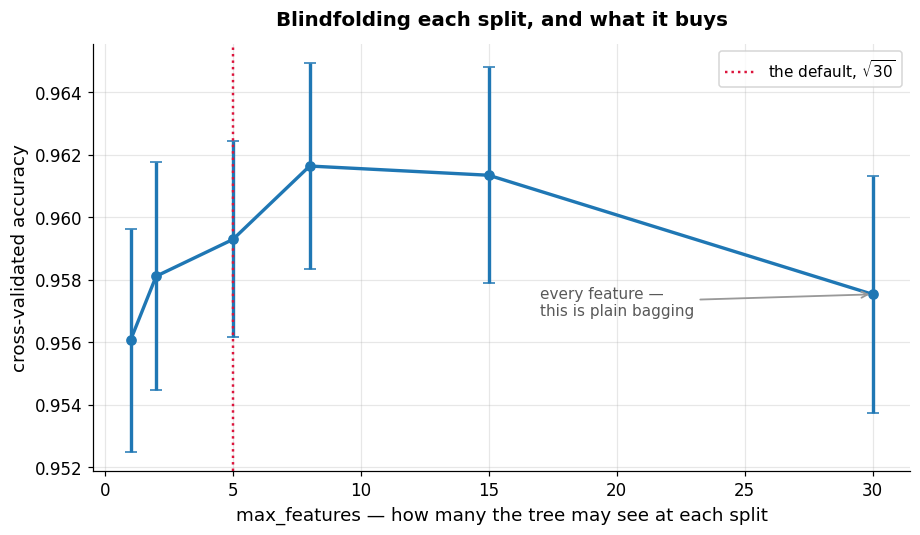

In [7]:
choices = [1, 2, 5, 8, 15, 30]
scored = {}
for many in choices:
    result = cross_val_score(RandomForestClassifier(n_estimators=300, max_features=many,
                                                    random_state=0), X, y, cv=subsets, n_jobs=-1)
    scored[many] = result

print(f"{'max_features':>13}{'accuracy':>11}{'std error':>12}")
for many, result in scored.items():
    note = "  <- sqrt(30), the default" if many == 5 else ("  <- every feature: this is bagging"
                                                           if many == 30 else "")
    print(f"{many:>13}{result.mean():>11.4f}{result.std() / np.sqrt(len(result)):>12.4f}{note}")

plt.figure(figsize=(8.5, 5))
middles = np.array([scored[m].mean() for m in choices])
errors = np.array([scored[m].std() / np.sqrt(len(scored[m])) for m in choices])
plt.errorbar(choices, middles, yerr=errors, marker="o", linewidth=2.2, capsize=4)
plt.axvline(5, color="crimson", linestyle=":", linewidth=1.6, label="the default, $\\sqrt{30}$")
plt.annotate("every feature —\nthis is plain bagging", xy=(30, middles[-1]),
             xytext=(17, middles.min() + 0.0008), fontsize=10, color="0.35",
             arrowprops={"arrowstyle": "->", "color": "0.6", "linewidth": 1.2})
plt.xlabel("max_features — how many the tree may see at each split")
plt.ylabel("cross-validated accuracy")
plt.title("Blindfolding each split, and what it buys")
plt.legend()
plt.show()

Read the size of the effect before the shape of it. The best setting beats plain bagging by about
four tenths of a percentage point, against standard errors of about three thousandths — real, but
small. **The trick that gives the method its name is worth a fraction of what bagging itself was
worth.** That is worth knowing before you spend an afternoon tuning it.

The shape is the textbook one all the same, and both ends are bad for reasons the argument
predicts. At `max_features=1` each split is made almost at random: the trees are maximally
decorrelated and individually poor, and the average inherits their poorness. At `max_features=30`
nothing is hidden, the trees converge on the same questions, and $\rho$ stops the average
improving. The interior optimum is the trade between those.

> $\sqrt{p}$ for classification and $p/3$ for regression are conventions, not results. They are
> reasonable defaults on this evidence — five is within a standard error of the best — and they are
> a hyperparameter like any other if the difference matters to you.

<div class="alert alert-success">
<b>Mini-exercise 1 — Where the trick earns its keep</b><br>
The effect above is small. It should be larger where one feature dominates.
<br><br>
1. Add a single very strong feature to this dataset — for instance <code>y</code> itself, corrupted
by flipping 15% of its values — and repeat the <code>max_features</code> sweep. Does the gap
between <code>max_features=5</code> and <code>max_features=30</code> widen?<br>
2. Measure the root question of thirty bagged trees on that modified data. How many take the
planted feature?<br>
3. From those two results, state in one sentence when you would expect the random-subspace trick to
matter and when you would not.
</div>

In [8]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. How many trees?

`04A` spent a section on depth because depth is a genuine bias–variance dial: too little underfits,
too much overfits, and the best value must be found. It is natural to expect `n_estimators` to
behave the same way.

It does not, and the reason is worth being precise about. Adding a tree does not give the model
more capacity to bend towards the training data — each tree is fitted independently of the others,
and averaging more of them simply estimates the same quantity more precisely. There is no value of
`n_estimators` that is *too many*; there is only a point past which more costs time and buys
nothing.

The next cell scores forests of 1, 3, 10, 30, 100 and 300 trees.

1. Does the curve have a maximum, or does it flatten?
2. Where would you stop, and what would stop you?

**Think about your answer before running this cell.**

In [ ]:
sizes = [1, 3, 10, 30, 100, 300]
by_size = {n: cross_val_score(RandomForestClassifier(n_estimators=n, random_state=0),
                              X, y, cv=subsets, n_jobs=-1) for n in sizes}

print(f"{'trees':>7}{'accuracy':>11}{'std error':>12}")
for n, result in by_size.items():
    print(f"{n:>7}{result.mean():>11.4f}{result.std() / np.sqrt(len(result)):>12.4f}")

plt.figure(figsize=(8.5, 5))
plt.errorbar(sizes, [by_size[n].mean() for n in sizes],
             yerr=[by_size[n].std() / np.sqrt(len(by_size[n])) for n in sizes],
             marker="o", linewidth=2.2, capsize=4)
plt.xscale("log")
plt.xticks(sizes, [str(n) for n in sizes])
plt.xlabel("number of trees")
plt.ylabel("cross-validated accuracy")
plt.title("More trees never hurts; it just stops helping")
plt.show()

The curve climbs steeply and then flattens. It does not turn over, and no amount of patience will
make it turn over — that is the difference between this dial and `04A`'s depth.

So `n_estimators` is not chosen by cross-validation. It is chosen by how long you are willing to
wait: take enough trees that the curve has visibly flattened, then a few more. A hundred is a
reasonable habit and the `scikit-learn` default; three hundred costs three times as much and, here,
returns nothing you could measure.

> This is the one hyperparameter in the course where "more is better" is simply true. Enjoy it. The
> boosting of `04C` looks similar and is not: there, the number of rounds *is* a flexibility dial,
> and too many of them overfits in the ordinary way.

# 6. Validation that costs nothing

Bagging leaves something behind that is easy to overlook.

Each tree is fitted to $n$ observations drawn with replacement from $n$. Some are drawn more than
once, and some are not drawn at all. The probability that a particular observation misses a
particular bootstrap is

$$
\Bigl(1 - \tfrac{1}{n}\Bigr)^{n} \;\longrightarrow\; e^{-1} \approx 0.368 ,
$$

so **about a third of the training set is invisible to any given tree**. Those are its
**out-of-bag** observations, and for each of them that tree is an honest, untrained-on predictor.

Collect, for every observation, the votes of only the trees that did not see it, and you have a
validation score computed on data the ensemble never fitted — without setting anything aside and
without refitting anything. `oob_score=True` asks for it.

In [10]:
measured = RandomForestClassifier(n_estimators=300, oob_score=True,
                                  random_state=0).fit(X, y)
five_fold = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=0),
                            X, y, cv=5, n_jobs=-1)

print(f"out-of-bag score          : {measured.oob_score_:.4f}   (one fit)")
print(f"five-fold cross-validation: {five_fold.mean():.4f}   (five fits)")

fraction = [(1 - 1 / n) ** n for n in [10, 100, 1000, 10000]]
print(f"\nfraction of the data left out of one bootstrap, as n grows:")
print("   " + "   ".join(f"n={n}: {f:.3f}" for n, f in zip([10, 100, 1000, 10000], fraction)))
print(f"   the limit, 1/e: {np.exp(-1):.3f}")

out-of-bag score          : 0.9649   (one fit)
five-fold cross-validation: 0.9631   (five fits)

fraction of the data left out of one bootstrap, as n grows:
   n=10: 0.349   n=100: 0.366   n=1000: 0.368   n=10000: 0.368
   the limit, 1/e: 0.368


The two agree to within a couple of thousandths, and the out-of-bag figure came from a single fit
rather than five. On a large dataset that is the difference between minutes and an hour.

Two cautions, because it is not free of assumptions.

- It is available **only for bagged ensembles**. Nothing analogous exists for a single tree, or for
  the boosting of `04C`, because there is no bootstrap to be left out of.
- It estimates the performance of an ensemble of about $B/3$ trees, not of your $B$. With few trees
  it is pessimistic; by a few hundred the difference has vanished.

> If you are choosing a hyperparameter, `02C`'s rule still stands: the score that chose the model
> cannot also evaluate it. Out-of-bag is a cheap way to *choose*; a held-out test set is still how
> you report.

# 7. Feature importance, and the three ways it lies

`04A` gave up interpretability the moment it went from one tree to two hundred. What comes back in
its place is a ranking: for each feature, how much did the ensemble rely on it?

The default in `scikit-learn` is **impurity importance**, sometimes called Gini importance. Every
split on a feature removed some impurity, weighted by how many samples reached it; add that up over
every node of every tree, normalise, and you have a number per feature. It is free, because the
tree recorded everything it needs while it was being built.

It is also, in three specific ways, misleading.

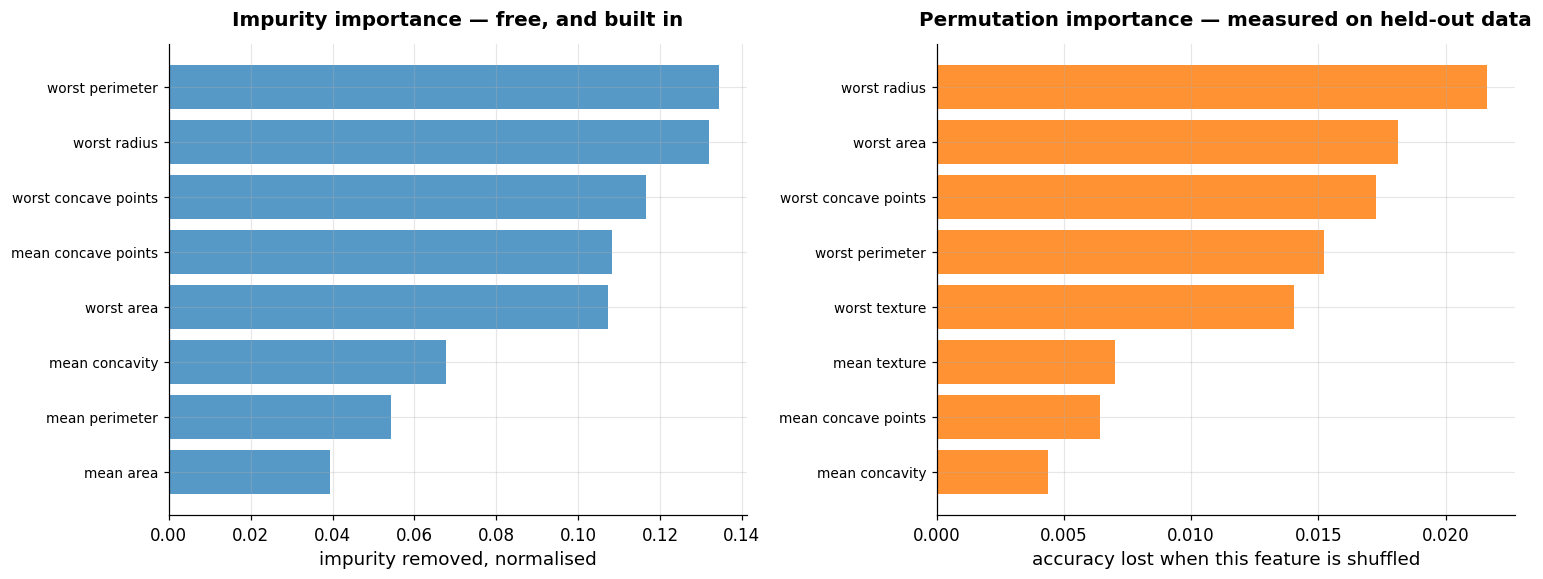

correlation between the top two impurity features
   worst perimeter and worst radius: 0.994


In [11]:
planted = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_train, y_train)
by_impurity = pd.Series(planted.feature_importances_, index=X.columns).sort_values(ascending=False)

shuffled = permutation_importance(planted, X_test, y_test, n_repeats=20,
                                  random_state=0, n_jobs=-1)
by_permutation = pd.Series(shuffled.importances_mean, index=X.columns).sort_values(ascending=False)

top = 8
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.4))
left.barh(range(top), by_impurity.head(top).to_numpy()[::-1], color="tab:blue", alpha=0.75)
left.set_yticks(range(top))
left.set_yticklabels(by_impurity.head(top).index[::-1], fontsize=9)
left.set_xlabel("impurity removed, normalised")
left.set_title("Impurity importance — free, and built in")

right.barh(range(top), by_permutation.head(top).to_numpy()[::-1], color="tab:orange", alpha=0.85)
right.set_yticks(range(top))
right.set_yticklabels(by_permutation.head(top).index[::-1], fontsize=9)
right.set_xlabel("accuracy lost when this feature is shuffled")
right.set_title("Permutation importance — measured on held-out data")
plt.show()

pair = by_impurity.index[:2]
print(f"correlation between the top two impurity features")
print(f"   {pair[0]} and {pair[1]}: {X[pair[0]].corr(X[pair[1]]):.3f}")

The two rankings do not agree, and the disagreement is the lesson.

**It rewards features that were *available*, not features that are *needed*.** The top two by
impurity correlate at 0.99 — they are very nearly the same measurement written twice. The forest
had to pick one at each split, so the credit was divided between them, and a third measurement that
carries the same information would divide it three ways. Read either one as "this measurement
matters twice as much as that one" and you are reading an artefact of how many near-copies of it
happen to be in the table.

**It is computed on the training data.** A feature the ensemble used to memorise noise scores just
as highly as one it used to generalise. Impurity importance cannot tell the difference, because it
never looks at data the model has not seen.

**It is biased towards features with many possible split points.** A continuous measurement offers
hundreds of thresholds to choose from and will beat a binary flag on impurity even when the flag is
more informative — the continuous one simply had more chances to look good.

**Permutation importance** answers a different and usually better question: shuffle one column of
the *held-out* data, so that feature becomes noise while everything else stays as it was, and
measure how much accuracy is lost. It is computed on data the model never saw, it asks about the
fitted model's actual reliance, and it applies to any model at all, not just trees.

> It inherits the correlation problem, and in a worse form. Shuffle one of two near-identical
> features and the model simply reads the other, so *both* score near zero and the pair looks
> unimportant. When features come in correlated groups, permute the **group**.

<div class="alert alert-success">
<b>Mini-exercise 2 — Importance of a column that means nothing</b><br>
1. Add a column of pure noise (<code>rng.normal</code>, one value per sample) to the training data
and refit the forest. Where does the noise column rank by impurity importance? Where by
permutation importance?<br>
2. Add instead a column of random integers between 0 and 500 — still meaningless, but with hundreds
of possible split points. Does its impurity importance rise?<br>
3. Take the two most correlated real features and shuffle them <b>together</b> rather than
separately. How does their joint permutation importance compare with the sum of their individual
ones?<br>
4. Which of the two measures would you report in a paper, and what would you say about it?
</div>

In [12]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 8. What a forest costs

Accuracy is not the only axis, and a forest is worse than a single tree on several of the others.

**Interpretability.** The largest cost and the least recoverable. `04A`'s tree was a flowchart you
could read to a collaborator; a forest is three hundred of them voting. Feature importance is a
summary of that, not a substitute for it.

**Prediction time and size.** Three hundred trees take three hundred times the memory and roughly
three hundred times the arithmetic per prediction. Usually irrelevant; occasionally decisive.

**It still cannot extrapolate.** Every tree in the forest is piecewise constant outside the training
range, so their average is too. `04A` §10's warning survives the ensemble unchanged, and averaging
does nothing about it.

**Its probabilities are better behaved than a tree's, but they are not calibrated.** A single tree
reports the class proportions of one leaf and so is wildly overconfident — often exactly 0 or 1. A
forest reports the fraction of trees voting each way, which `03A` §8 predicts will be pulled in from
the extremes, since it takes unanimity to reach 0 or 1. Better is not the same as right: check it
with `03A` §8's calibration curve before treating a forest's output as a probability.

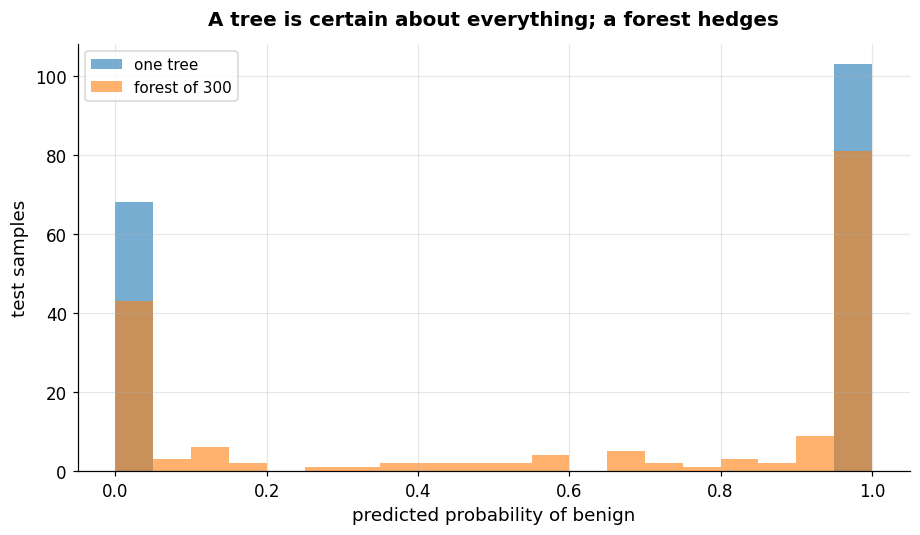

      one tree: 100.0 % of predictions are exactly 0 or 1
 forest of 300:  32.2 % of predictions are exactly 0 or 1


In [13]:
single = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
crowd = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_train, y_train)

fig, axis = plt.subplots(figsize=(8.5, 5))
axis.hist(single.predict_proba(X_test)[:, 1], bins=20, alpha=0.6, label="one tree",
          color="tab:blue")
axis.hist(crowd.predict_proba(X_test)[:, 1], bins=20, alpha=0.6, label="forest of 300",
          color="tab:orange")
axis.set_xlabel("predicted probability of benign")
axis.set_ylabel("test samples")
axis.set_title("A tree is certain about everything; a forest hedges")
axis.legend()
plt.show()

for name, model in [("one tree", single), ("forest of 300", crowd)]:
    probability = model.predict_proba(X_test)[:, 1]
    extreme = ((probability == 0) | (probability == 1)).mean()
    print(f"{name:>14}: {100 * extreme:5.1f} % of predictions are exactly 0 or 1")

The single tree puts almost everything at 0 or 1, because a leaf is usually pure and a pure leaf
reports certainty. The forest spreads out: to reach 1.0 it needs all three hundred trees to agree,
and on the difficult samples they do not.

That spread is what makes a forest's output usable as a ranking, and it is why `03A` §7's ROC and
average precision mean something for a forest and very little for a single tree.

# 9. Common pitfalls

**Reporting a single tree's structure from inside a forest.** There is no representative tree. The
ensemble's answer is the average; no member of it is the model.

**Tuning `n_estimators` by cross-validation.** Section 5: the curve does not turn over, so the
search will always tell you to use more. Choose it by patience, not by score.

**Reading impurity importance as scientific evidence.** Section 7, all three ways. If a ranking is
going into a paper, use permutation importance on held-out data, permute correlated features as a
group, and say which you used.

**Expecting the forest to fix extrapolation.** It cannot. Averaging piecewise-constant functions
gives a piecewise-constant function.

**Using out-of-bag as both selector and report.** `02C` §5's rule does not lapse because the score
was cheap.

**Forgetting that a forest of stumps is not a forest.** The variance reduction argument assumes the
members are low-bias. Depth-limit the trees hard enough and you have averaged a set of underfitted
models, which averaging cannot repair.

# Key Takeaways

- A single tree is low-bias and high-variance. **Bagging** — bootstrap the training set, fit a tree
  to each resample, aggregate the votes — divides the variance without touching the bias, and on
  this dataset removes just under three percentage points of error.
- Bagged trees are **correlated**, because they all run the same greedy search on the same features.
  Correlation $\rho$ leaves a floor of $\rho\sigma^2$ that no number of trees can get below.
- A **random forest** is bagging plus one trick: a fresh random subset of features at every split,
  set by `max_features`. It decorrelates the trees at the cost of making each slightly worse. Here
  it was worth about 0.4 percentage points — real, and far less than bagging itself.
- **More trees never overfits.** `n_estimators` is chosen by patience; depth is chosen by
  cross-validation. Do not confuse the two dials.
- **Out-of-bag** scoring is validation from the samples each tree did not see — about $1/e$ of them
  — for the price of one fit.
- **Feature importance misleads in three ways**: it splits credit between correlated features, it
  is computed on training data, and it favours features with more split points. Permutation
  importance on held-out data fixes two of the three; permuting correlated features as a group
  fixes the first.

# Optional preparation for the next notebook

Before `04C`, students should be comfortable with:

- what bagging averages, and why the members must be low-bias for it to work;
- reading a cross-validated score with its standard error, and not over-reading a difference
  smaller than one;
- `04A`'s trees, especially depth as a flexibility dial.

`04C` builds an ensemble the other way round. A forest grows many strong trees independently and
averages away their variance; **gradient boosting** grows many *deliberately weak* trees in
sequence, each one fitted to what the ones before it got wrong. The members are high-bias by design
and the ensemble reduces bias rather than variance — which is why the number of rounds is a
flexibility dial that overfits, exactly the dial section 5 said `n_estimators` was not.